### Understanding Scikit-Learn, a learning tool kit that contains implementations of various ML algorithms

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
np.set_printoptions(precision=2)

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

d:\Study_Resources\Machine Learning Specialization\Coursera\Coursera_Machine_Learning\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 4.63k/4.63k [00:00<00:00, 4.53MB/s]

Extracting files...
Path to dataset files: C:\Users\sayed mohamed saqib\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1


In [27]:
df = pd.read_csv("Housing.csv")
X_features = df[["bedrooms", "area", "bathrooms", "stories","basement", "hotwaterheating", "airconditioning", "guestroom", "mainroad"]]
print(X_features)

     bedrooms  area  bathrooms  stories basement hotwaterheating  \
0           4  7420          2        3       no              no   
1           4  8960          4        4       no              no   
2           3  9960          2        2      yes              no   
3           4  7500          2        2      yes              no   
4           4  7420          1        2      yes              no   
..        ...   ...        ...      ...      ...             ...   
540         2  3000          1        1      yes              no   
541         3  2400          1        1       no              no   
542         2  3620          1        1       no              no   
543         3  2910          1        1       no              no   
544         3  3850          1        2       no              no   

    airconditioning guestroom mainroad  
0               yes        no      yes  
1               yes        no      yes  
2                no        no      yes  
3               yes

========== DATASET OVERVIEW ==========
Shape: (545, 13)

Columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

========== DATA TYPES ==========
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

========== FIRST 5 ROWS ==========


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



========== RANDOM SAMPLE ==========


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
30,8400000,7475,3,2,4,yes,no,no,no,yes,2,no,unfurnished
417,3395000,3640,2,1,1,yes,no,no,no,no,0,no,furnished
211,4900000,12900,3,1,1,yes,no,no,no,no,2,no,furnished
82,6615000,10500,3,2,1,yes,no,yes,no,yes,1,yes,furnished
364,3703000,3120,3,1,2,no,no,yes,yes,no,0,no,semi-furnished



========== MISSING VALUES ==========


...

C:\Users\sayed mohamed saqib\AppData\Local\Temp\ipykernel_20816\4082348868.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64


========== CORRELATION MATRIX (NUMERIC FEATURES) ==========


,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000



========== PEAK-TO-PEAK RANGE ==========
price        11550000
area            14550
bedrooms            5
bathrooms           3
stories             3
parking             3
dtype: int64

========== HISTOGRAMS ==========


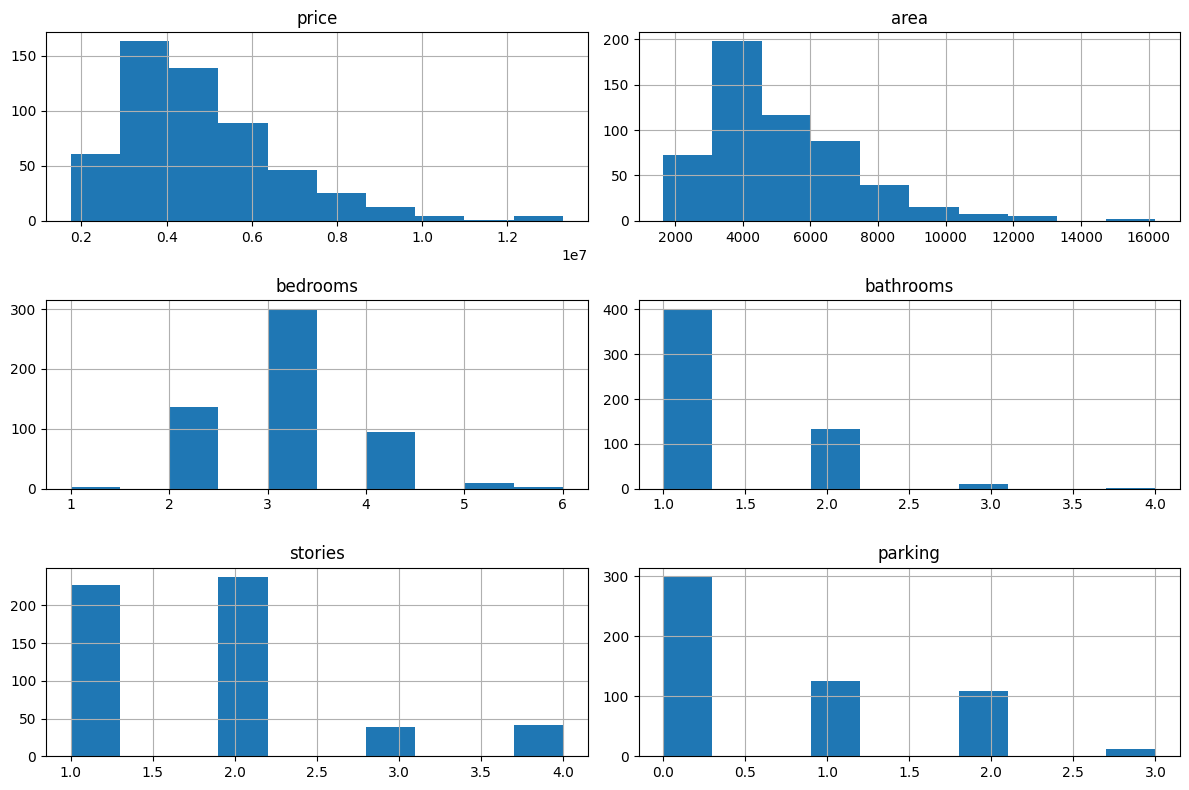


========== OUTLIER CHECK (IQR METHOD) ==========


price        15
area         12
bedrooms     12
bathrooms     1
stories      41
parking      12
dtype: int64


========== DATASET HEALTH SUMMARY ==========
Total rows: 545
Total columns: 13
Numeric features: 6
Categorical features: 7
Duplicate rows: 0
Columns with missing values: 0


In [34]:

# ================================
# DATASET HEALTH SUMMARY
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("========== DATASET OVERVIEW ==========")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== FIRST 5 ROWS ==========")
display(df.head())

print("\n========== RANDOM SAMPLE ==========")
display(df.sample(5))

print("\n========== MISSING VALUES ==========")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percent": missing_percent
})
display(missing_df[missing_df["Missing Values"] > 0])

print("\n========== DUPLICATES ==========")
print("Duplicate rows:", df.duplicated().sum())

print("\n========== NUMERIC SUMMARY ==========")
display(df.describe())

print("\n========== CATEGORICAL SUMMARY ==========")
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())

print("\n========== UNIQUE VALUES PER COLUMN ==========")
display(df.nunique())

print("\n========== CORRELATION MATRIX (NUMERIC FEATURES) ==========")
corr = df.corr(numeric_only=True)
display(corr)

print("\n========== PEAK-TO-PEAK RANGE ==========")
numeric_df = df.select_dtypes(include=np.number)
print(np.ptp(numeric_df, axis=0))

print("\n========== HISTOGRAMS ==========")
numeric_df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

print("\n========== OUTLIER CHECK (IQR METHOD) ==========")
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).sum()
display(outliers)

print("\n========== DATASET HEALTH SUMMARY ==========")
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])
print("Numeric features:", len(df.select_dtypes(include=np.number).columns))
print("Categorical features:", len(cat_cols))
print("Duplicate rows:", df.duplicated().sum())
print("Columns with missing values:", (df.isnull().sum() > 0).sum())



In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

yes_no_cols = ["mainroad","guestroom","basement","hotwaterheating","airconditioning"]

for col in yes_no_cols:
    X_features[col] = X_features[col].astype(str).str.strip().str.lower()
    X_features[col] = (X_features[col] == "yes").astype(int)

scaler = StandardScaler()
X_norm = scaler.fit_transform(X_features)

y_train = df[["price"]]

print(f"Peak to Peak range by column in Raw        X:{np.ptp(X_features,axis=0)}")
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X_norm,axis=0)}")

Peak to Peak range by column in Raw        X:bedrooms               5
area               14550
bathrooms              3
stories                3
basement               0
hotwaterheating        0
airconditioning        0
guestroom              0
mainroad               0
dtype: int64
Peak to Peak range by column in Normalized X:[6.78 6.71 5.98 3.46 0.   0.   0.   0.   0.  ]


In [37]:
sgdr = SGDRegressor(max_iter = 1000)
sgdr.fit(X_norm, y_train)
print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

SGDRegressor()
number of iterations completed: 17, number of weight updates: 9266.0


d:\Study_Resources\Machine Learning Specialization\Coursera\Coursera_Machine_Learning\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [23]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")

model parameters:                   w: [142721.04 821046.71 597446.58 459879.77], b:[4759678.92]


In [24]:
y_pred_sgd = sgdr.predict(X_norm)
y_pred = np.dot(X_norm, w_norm) + b_norm
print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

print(f"Prediction on training set:\n{y_pred[:4]}" )
print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[ 7302658.21 10796671.66  7540357.19  6802340.65]
Target values 
      price
0  13300000
1  12250000
2  12250000
3  12215000


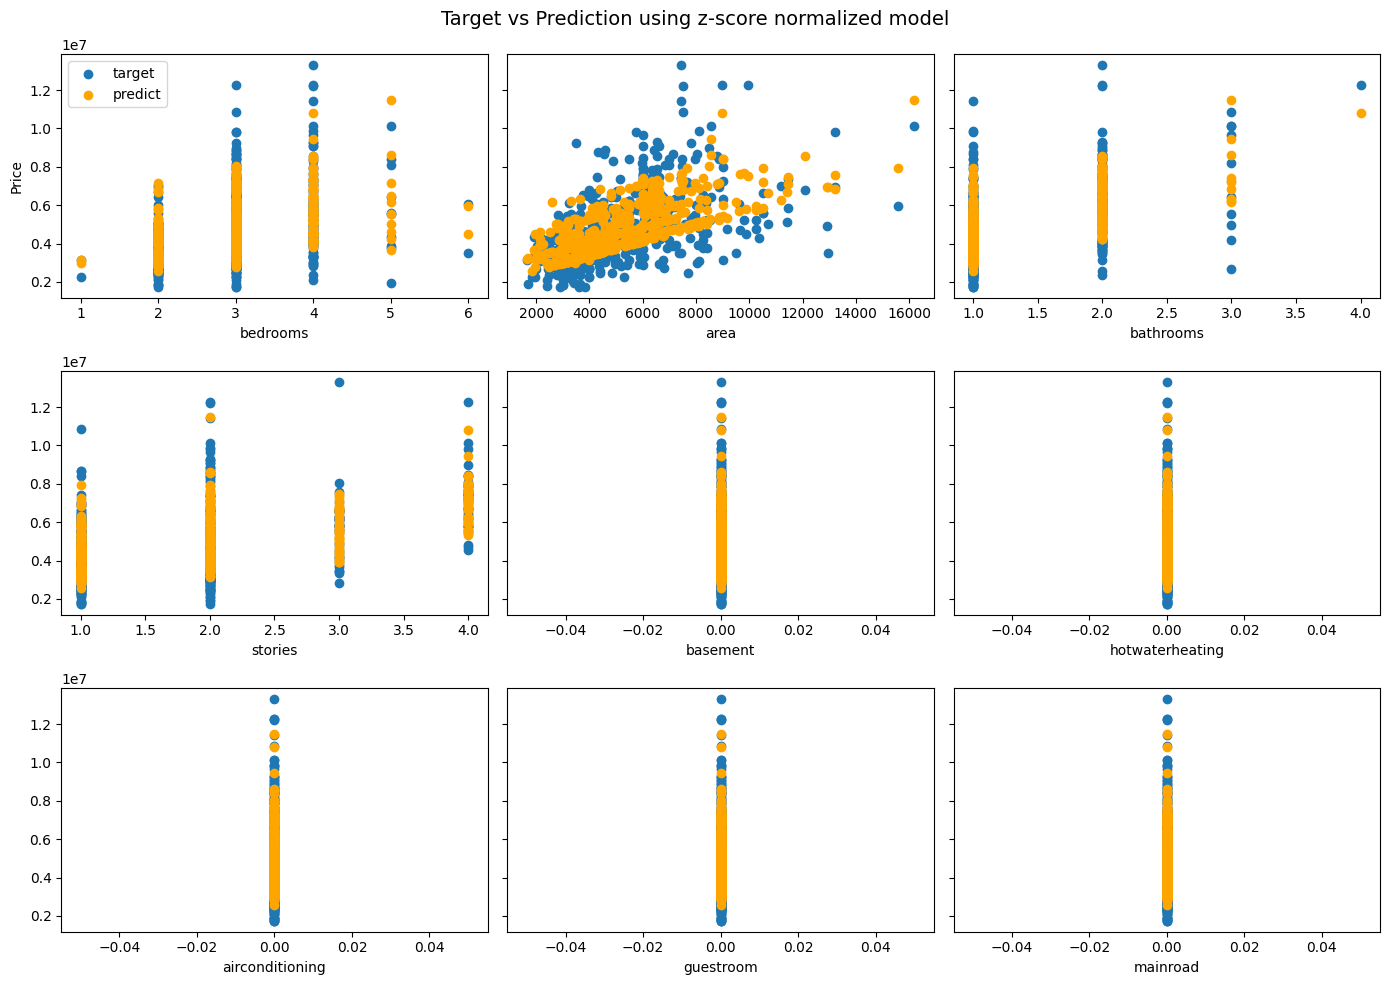

In [41]:
fig, ax = plt.subplots(3,3,figsize=(14,10),sharey=True)
ax = ax.flatten()

for i in range(len(X_features.columns)):
    ax[i].scatter(X_features.iloc[:, i], y_train, label='target')
    ax[i].scatter(X_features.iloc[:, i], y_pred, color="orange", label='predict')
    ax[i].set_xlabel(X_features.columns[i])

ax[0].set_ylabel("Price")
ax[0].legend()

fig.suptitle("Target vs Prediction using z-score normalized model", fontsize=14)

plt.tight_layout()
plt.show()